In [ ]:
!pip install tensorflow nltk wordcloud scikit-learn seaborn



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
data = pd.read_csv('/content/spam_ham_dataset.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [ ]:
data.shape

(5171, 4)

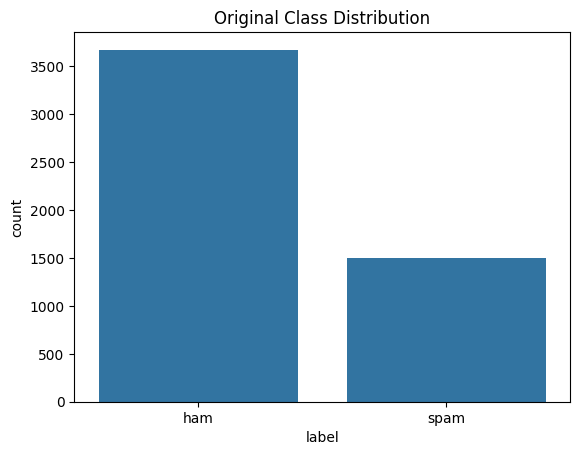

In [ ]:
sns.countplot(x='label', data=data)
plt.title("Original Class Distribution")
plt.show()


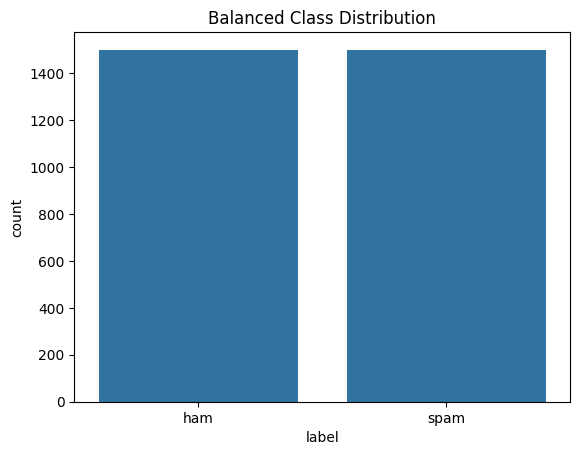

In [ ]:
ham = data[data['label'] == 'ham']
spam = data[data['label'] == 'spam']

ham_balanced = ham.sample(n=len(spam), random_state=42)
balanced_data = pd.concat([ham_balanced, spam]).reset_index(drop=True)

sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Class Distribution")
plt.show()


In [ ]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')


In [ ]:

balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [ ]:
def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

balanced_data['text'] = balanced_data['text'].apply(remove_punctuation)


In [ ]:
stop_words = stopwords.words('english')

def remove_stopwords(text):
    return " ".join([word.lower() for word in text.split() if word.lower() not in stop_words])

balanced_data['text'] = balanced_data['text'].apply(remove_stopwords)
balanced_data.head()


,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


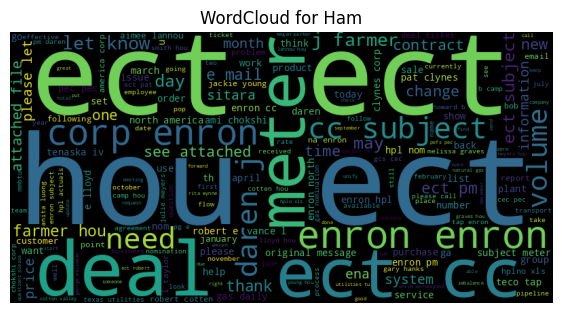

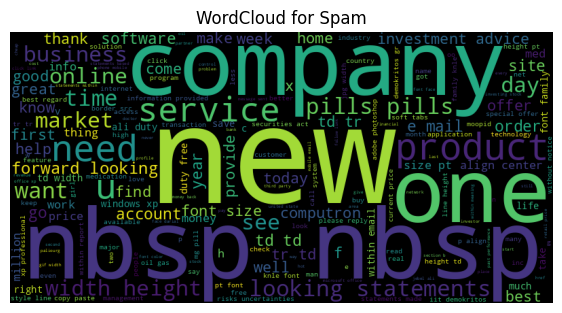

In [ ]:
def wordcloud_plot(df, label):
    text = " ".join(df['text'])
    wc = WordCloud(background_color='black', width=800, height=400).generate(text)
    plt.figure(figsize=(7,5))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"WordCloud for {label}")
    plt.show()

wordcloud_plot(balanced_data[balanced_data['label']=='ham'], "Ham")
wordcloud_plot(balanced_data[balanced_data['label']=='spam'], "Spam")


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    balanced_data['text'],
    balanced_data['label'],
    test_size=0.2,
    random_state=42
)


In [ ]:
y_train = (y_train == 'spam').astype(int)
y_test = (y_test == 'spam').astype(int)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),   # 👈 Explicit input
    tf.keras.layers.Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=64
    ),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 64)        │     2,549,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,563,329 (9.78 MB)

 Trainable params: 2,563,329 (9.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
)


In [ ]:
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, lr_reduce]
)


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9717 - loss: 0.1284 - val_accuracy: 0.9583 - val_loss: 0.1577 - learning_rate: 5.0000e-04
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.9749 - loss: 0.1124 - val_accuracy: 0.9600 - val_loss: 0.1586 - learning_rate: 5.0000e-04
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9783 - loss: 0.1017 - val_accuracy: 0.9617 - val_loss: 0.1518 - learning_rate: 5.0000e-04
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9810 - loss: 0.0936 - val_accuracy: 0.9617 - val_loss: 0.1532 - learning_rate: 5.0000e-04
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.9864 - loss: 0.0727 - val_accuracy: 0.9617 - val_loss: 0.1557 - learning_rate: 5.0000e-04
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9864 - loss: 0.0708 - val_accuracy: 0.9617 - val_loss: 0.1570 - learning_rate: 5.0000e-04


In [ ]:
model.save('/content/spam_detection_model.h5')


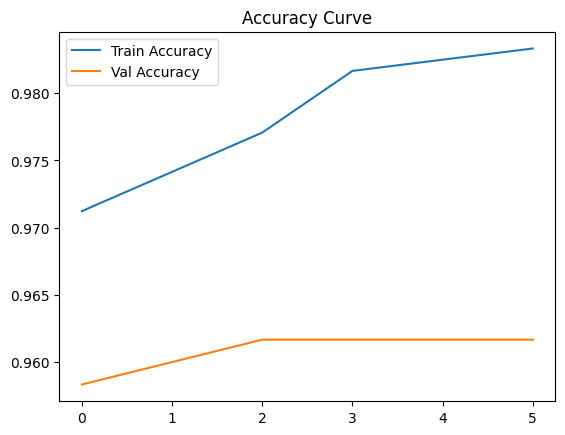

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test_pad) > 0.5).astype(int)

print(classification_report(y_test, y_pred))


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       315
           1       0.96      0.96      0.96       285

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



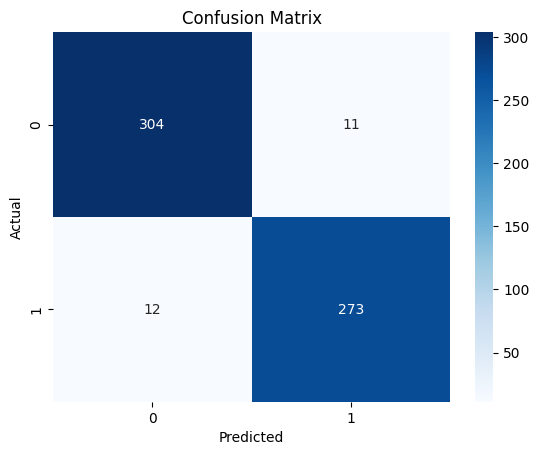

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
y_probs = model.predict(X_test_pad).ravel()


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


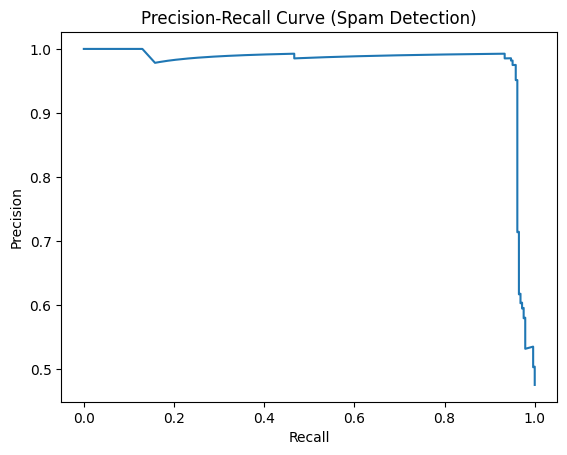

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Spam Detection)")
plt.show()


In [ ]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)


Best Threshold: 0.9515959


In [ ]:
y_pred_opt = (y_probs >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_opt))


              precision    recall  f1-score   support

           0       0.96      0.98      0.97       315
           1       0.97      0.96      0.97       285

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



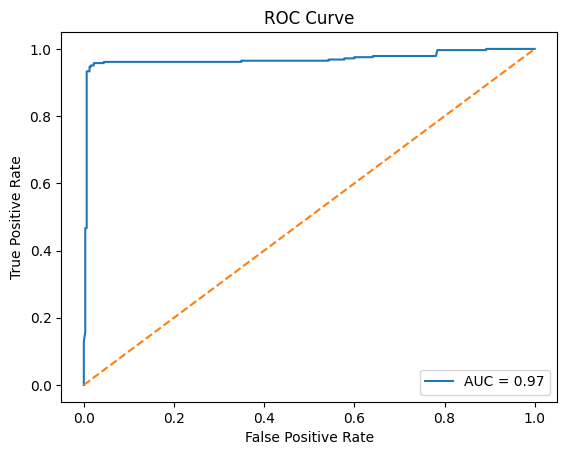

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
!pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4bcf1ef24ece0b0632985cd8dfab58714f311a7937a7355a0f662ee012412470
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime.lime_text import LimeTextExplainer

class_names = ['Ham', 'Spam']

def predict_spam(texts):
    seq = tokenizer.texts_to_sequences(texts)
    pad = pad_sequences(seq, maxlen=max_len, padding='post')
    preds = model.predict(pad)
    return np.hstack([1 - preds, preds])


In [ ]:
explainer = LimeTextExplainer(class_names=class_names)

sample_text = X_test.iloc[5]   # any test email
print("Email Text:\n", sample_text)

exp = explainer.explain_instance(
    sample_text,
    predict_spam,
    num_features=10
)

exp.show_in_notebook(text=True)


Email Text:
 hpl nom march 13 2001 see attached file hplno 313 xls hplno 313 xls
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
